# Programming Python for Bioinformatics (WBT-MBT2-25E)

---

### Wojciech Dec
### Part 5 - Re and Biopython Basics

### Regular Expressions

We will become familiar with the `re` module from the Python standard library.

In particular, we will focus on the functions:

* `search`
* `findall`
* `finditer`

and on basic regular expression syntax.

Regular expressions (*regex*) originate from *formal language theory*, specifically from *regular languages*. These can be interpreted using finite automata—abstract machines that accept a string if a sequence of input symbols leads to an accepting state.

In practice, regular expressions are widely used to search for patterns in text data.

Documentation: https://docs.python.org/3/library/re.html

#### Special Characters

| Symbol | Meaning                                          |
| ------ | ------------------------------------------------ |
| `.`    | any character except newline (`\n`)              |
| `?`    | zero or one occurrence                           |
| `*`    | zero or more occurrences                         |
| `+`    | one or more occurrences                          |
| `^`    | start of string                                  |
| `$`    | end of string                                    |
| `[]`   | any character from the set                       |
| `[^]`  | any character not in the set                     |
| `{}`   | number of occurrences (e.g., `{n}`, `{min,max}`) |
| `A\|B` | A or B (alternation, can be expressions)         |


#### Character Classes

| Pattern | Meaning                                 |
| ------- | --------------------------------------- |
| `\d`    | any digit (0–9)                         |
| `\D`    | any non-digit (`[^0-9]`)                |
| `\s`    | whitespace character                    |
| `\S`    | non-whitespace character                |
| `\w`    | alphanumeric (`a-z`, `A-Z`, `0-9`, `_`) |
| `\W`    | non-alphanumeric                        |
| `\b`    | word boundary (between `\w` and `\W`)   |


#### Basic examples

* Find digits in text

In [4]:
import re

text = "Sample ID: A12, B345, C7"
re.findall(r"\d+", text)

['12', '345', '7']

* Finding phone numbers and email adresses

In [3]:
text = "Contact: +48 123 456 789, email: test.user@example.com"

phone_numbers = re.findall(r"\+?\d{2,3}[- ]?\d{3}[- ]?\d{3}[- ]?\d{3}", text)
print(phone_numbers)

email_addresses = re.findall(r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}", text)
print(email_addresses)

['+48 123 456 789']
['test.user@example.com']


* Other examples

In [ ]:
r"[ATGC]+"           # DNA sequence
r"[AUGC]+"           # RNA sequence
r"ATG[ATGC]{3,}"     # start codon + at least one codon
r"(AT){3}"           # AT repeated exactly 3 times
r"(AG)+"             # AG repeated one or more times
r"^ATG"              # starts with ATG
r"TAA$"              # ends with TAA
r"\b[0-9][A-Za-z0-9]{3}\b" # PDB IDs

Why use raw strings (`r""`) in regex?

In [7]:
# raw string (r) treats '\' as a literal character
print(len("\n"), len(r"\n"))

1 2


#### Grouping

| Pattern        | Meaning                                                            |
| -------------- | ------------------------------------------------------------------ |
| `()`           | groups part of the pattern; the matched substring can be extracted |
| `(?P<key>...)` | named group; assigns name `key` to the matched substring           |


In [6]:
text = "Gene: BRCA1, ID: 1234"

match = re.search(r"Gene: (\w+), ID: (?P<id>\d+)", text)

print(match.group(1))
print(match.group("id"))

BRCA1
1234


#### Greedy vs Non-Greedy Matching

* Greedy: match as much as possible
* Non-greedy: match as little as possible
* `?` after a quantifier makes it non-greedy

In [8]:
text = "HaHaHaHaHaHaHa"

greedy_regex = re.compile(r"(Ha){1,5}")
result1 = greedy_regex.search(text)

# '?' modifies the quantifier: makes it non-greedy (minimal match)
nongreedy_regex = re.compile(r"(Ha){1,5}?")
result2 = nongreedy_regex.search(text)

print(result1)
print(result2)

<re.Match object; span=(0, 10), match='HaHaHaHaHa'>
<re.Match object; span=(0, 2), match='Ha'>


#### `re.findall` - extracting multiple matches

In [9]:
text = """
Holy Grail Ave 42/1 42-022 Camelot
Spam Street 7/3 81-426 Pythonia
Genome Road 101/5 30-654 BioCity
"""

expr = r" (\d{2}-\d{3}) ([A-Za-z]+)"

matches = re.findall(expr, text)
print(matches)

[('42-022', 'Camelot'), ('81-426', 'Pythonia'), ('30-654', 'BioCity')]


#### Named Groups

In [12]:
expr_w_names = r" (?P<zcode>\d{2}-\d{3}) (?P<city>.+)\n"

match = re.search(expr_w_names, text)
gdict = match.groupdict()

print(gdict)

{'zcode': '42-022', 'city': 'Camelot'}


#### Use `re.finditer()` to keep group names in the output

In [13]:
for m in re.finditer(expr_w_names, text):
    print(m.groupdict())

{'zcode': '42-022', 'city': 'Camelot'}
{'zcode': '81-426', 'city': 'Pythonia'}
{'zcode': '30-654', 'city': 'BioCity'}


#### Lookahead and Lookbehind Assertions

| Pattern   | Meaning                                                         |
| --------- | --------------------------------------------------------------- |
| `A(?=B)`  | match `A` only if followed by `B` (positive lookahead)          |
| `A(?!B)`  | match `A` only if **not** followed by `B` (negative lookahead)  |
| `(?<=B)A` | match `A` only if preceded by `B` (positive lookbehind)         |
| `(?<!B)A` | match `A` only if **not** preceded by `B` (negative lookbehind) |

* Lookarounds do not consume characters (they assert context)
* Lookbehind in Python must have fixed length


Examples:

In [15]:
text = "ATGAAA TAG ATGCCC"

# ATG only if followed by A
m1 = re.findall(r"ATG(?=A)", text)

# ATG not followed by A
m2 = re.findall(r"ATG(?!A)", text)

# AAA only if preceded by ATG
m3 = re.findall(r"(?<=ATG)AAA", text)

### Biopython Basics

Biopython is a Python library for working with biological data such as:

- Nucleic and protein sequences
- FASTA and GenBank files etc.
- alignments
- biological databases

A plain Python string can store a sequence, but Biopython provides a special object called `Seq` that is designed for biological sequence operations.

In [18]:
from Bio.Seq import Seq

dna = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")
print(dna)
print(type(dna))

ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
<class 'Bio.Seq.Seq'>


In [20]:
print("\nTranscription:")
print(dna.transcribe())

print("\nReverse complement:")
print(dna.reverse_complement())

print("\nTranslation:")
print(dna.translate()) # table='Standard', stop_symbol='*'


Transcription:
AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG

Reverse complement:
CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT

Translation:
MAIVMGR*KGAR*


Biological sequences often come with extra information, we can store and access those using the `SeqRecord` class.

In [21]:
from Bio.SeqRecord import SeqRecord

record = SeqRecord(
    Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"),
    id="gene_001",
    name="example_gene",
    description="Example coding sequence"
)

print(record)

ID: gene_001
Name: example_gene
Description: Example coding sequence
Number of features: 0
Seq('ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG')


In [22]:
print("ID:", record.id)
print("Name:", record.name)
print("Description:", record.description)
print("Sequence:", record.seq)
print("Sequence length:", len(record.seq))

ID: gene_001
Name: example_gene
Description: Example coding sequence
Sequence: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Sequence length: 39


#### Reading FASTA data with SeqIO
Let's read the sequence data from the `data.fasta` file into `SeqRecord` objects

In [25]:
from Bio import SeqIO

for rec in SeqIO.parse("data.fasta", "fasta"):
    print(type(rec))
    print("ID:", rec.id)
    print("Description:", rec.description)
    print("Sequence:", rec.seq)
    print("Length:", len(rec.seq))
    print("-" * 40)
    break

<class 'Bio.SeqRecord.SeqRecord'>
ID: NP_001401927.1
Description: NP_001401927.1 uncharacterized LOC128125816 [Homo sapiens]
Sequence: MPASSTVHVLQLLRELLAFVLLSYTVLIGALLLAGWTTYFLVLK
Length: 44
----------------------------------------


#### `SeqIO.read()` vs `SeqIO.parse()`

- `SeqIO.read()` is for files with **exactly one** sequence
- `SeqIO.parse()` is for files with **one or more** sequences

Let's collect the records into a list.

In [27]:
records = list(SeqIO.parse("data.fasta", "fasta"))
print("Number of records:", len(records))

Number of records: 8


#### Writing sequences to a FASTA file

You can also create sequence records in Python and write them out to a FASTA file.

In [28]:
record_a = SeqRecord(Seq("ATGCGTACGTA"), id="sampleA", description="sample A")
record_b = SeqRecord(Seq("ATGCGTTCGTA"), id="sampleB", description="sample B")

SeqIO.write([record_a, record_b], "output.fasta", "fasta")

2

#### Pairwise alignment with `PairwiseAligner`

In [37]:
from Bio.Align import PairwiseAligner

aligner = PairwiseAligner()
aligner.mode = "global"

seq1 = "ACCGTAAGG"
seq2 = "ACGAAGGG"

alignments = aligner.align(seq1, seq2)

print("Number of alignments found:", len(alignments))
print("Best alignment score:", alignments.score)
print()
print(alignments[0])

Number of alignments found: 6
Best alignment score: 7.0

target            0 ACCGTAAGG-  9
                  0 ||-|-||||- 10
query             0 AC-G-AAGGG  8



We can adjust the alignment scoring parameters:

In [40]:
aligner = PairwiseAligner()
aligner.mode = "global"
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -2
aligner.extend_gap_score = -0.5

alignments = aligner.align("ACCGT", "ACG")
print("Best alignment score:", alignments.score)
print()
print(alignments[0])

Best alignment score: 2.0

target            0 ACCGT 5
                  0 |-||- 5
query             0 A-CG- 3



#### Aligning two protein sequences
BLOSUM62 is a substitution matrix used to score how likely one amino acid is to replace another during protein evolution.
* BLOSUM = BLOcks SUbstitution Matrix
* 62 = 62% identity threshold (used for matrix construction)
* Identity is the percentage of exactly matching residues, while similarity also counts biologically similar substitutions, with commonly used substitution matrices available in Biopython via `substitution_matrices`

In [35]:
from Bio.Align import substitution_matrices

seq1 = records[2].seq
seq2 = records[3].seq

aligner = PairwiseAligner()
aligner.mode = "global"

# Better for proteins than simple match/mismatch scoring
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")

# Typical-style affine gap penalties
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

alignments = aligner.align(seq1, seq2)

print("Best score:", alignments.score)
print(alignments[0])

Best score: 2285.5
target            0 MAAHLSYGRVNLNVLREAVRRELREFLDKCAGS-KAIVWDEYLTGPFGLIAQYSLLKEHE
                  0 |....|------.|...|-----------|.|.-.|||||||||||||||||||||||||
query             0 MSWFTS------GVSSAA-----------CRGTGRAIVWDEYLTGPFGLIAQYSLLKEHE

target           59 VEKMFTLKGNRLPAADVKNIIFFVRPRLELMDIIAENVLSEDRRGPTRDFHILFVPRRSL
                 60 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query            43 VEKMFTLKGNRLPAADVKNIIFFVRPRLELMDIIAENVLSEDRRGPTRDFHILFVPRRSL

target          119 LCEQRLKDLGVLGSFIHREEYSLDLIPFDGDLLSMESEGAFKECYLEGDQTSLYHAAKGL
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           103 LCEQRLKDLGVLGSFIHREEYSLDLIPFDGDLLSMESEGAFKECYLEGDQTSLYHAAKGL

target          179 MTLQALYGTIPQIFGKGECARQVANMMIRMKREFTGSQNSIFPVFDNLLLLDRNVDLLTP
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
query           163 MTLQALYGTIPQIFGKGECARQVANMMIRMKREFTGSQNSIFPVFDNLLLLDRNVDLLTP

targe

Biopython can also run external MSA programs and read their results, but these tools must be installed separately.

#### Protein Analysis Module

In [70]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

analysis = ProteinAnalysis("MVLSPADKTNVKAAW")

print("Molecular weight:", analysis.molecular_weight())
print("Isoelectric point:", analysis.isoelectric_point())
print(analysis.count_amino_acids())

Molecular weight: 1630.9055000000003
Isoelectric point: 8.344997215270997
{'A': 3, 'C': 0, 'D': 1, 'E': 0, 'F': 0, 'G': 0, 'H': 0, 'I': 0, 'K': 2, 'L': 1, 'M': 1, 'N': 1, 'P': 1, 'Q': 0, 'R': 0, 'S': 1, 'T': 1, 'V': 2, 'W': 1, 'Y': 0}


#### Sequence motifs

In [72]:
from Bio import motifs
from Bio.Seq import Seq

# Input sequences
sequences = [
    Seq("ATGCA"),
    Seq("ATGGA"),
    Seq("ATGAA"),
    Seq("ATGCT"),
]

# Create motif
m = motifs.create(sequences)

# Basic outputs
print("Consensus:", m.consensus)
print("Counts:\n", m.counts)

# Search for motif in a longer sequence
long_seq = Seq("TTTATGCAAAATGGATTT")

for position, score in m.pssm.search(long_seq):
    print("Match at position:", position, "score:", score)

Consensus: ATGCA
Counts:
         0      1      2      3      4
A:   4.00   0.00   0.00   1.00   3.00
C:   0.00   0.00   0.00   2.00   0.00
G:   0.00   0.00   4.00   1.00   0.00
T:   0.00   4.00   0.00   0.00   1.00

Match at position: 3 score: 8.584963
Match at position: 10 score: 7.5849624


#### Restriction anaylsys with `Bio.Restriction`
Restriction enzymes recognize specific DNA sequences and cut the DNA at those sites. Biopython provides tools to search sequences for restriction sites and analyze enzyme activity.

In [55]:
from Bio.Restriction import RestrictionBatch, AllEnzymes, CommOnly, Analysis

seq = Seq("AAGAATAGCT")

# CommOnly = commercially available according to the REBASE database
rb = RestrictionBatch(AllEnzymes) # check CommOnly
result = rb.search(seq)

# Show only enzymes that cut
for enzyme, sites in result.items():
    if sites:
        print(f"{enzyme}: {sites}")

AluBI: [9]
RlaI: [7, 8]
CviJI: [9]
AluI: [9]
CviKI_1: [9]
BmeDI: [3, 8]


In [50]:
from Bio.Restriction import EcoRI, KpnI, EcoRV

print(EcoRI.elucidate())
print(EcoRI.frequency())
print(EcoRI.neoschizomers())
print(EcoRI.equischizomers())
print(EcoRI.isoschizomers())

G^AATT_C
4096.0
[]
[]
[]


#### Use `RestrictionBatch` and `Analysis` for checking multiple enzymes

In [53]:
rb3 = EcoRI + KpnI + EcoRV # creates a RestrictionBatch object

new_seq = Seq('TTCAAAAAAAAAAAAAAAGAATTCAAAAAAAAAAAAAGAA')
rb3.search(new_seq)

{EcoRI: [20], EcoRV: [], KpnI: []}

In [57]:
rb = RestrictionBatch([EcoRI, KpnI, EcoRV])
ana = Analysis(rb, new_seq, linear=False)
ana.full()

{EcoRI: [20, 39], EcoRV: [], KpnI: []}

#### Plotting Annotated Sequences with DnaFeaturesViewer

(<Axes: >,
 ({GF(Small feature, 0-20 (1)): 0,
   GF(Gene 1 with a very long name, 20-500 (1)): 0,
   GF(Gene 2, 400-700 (-1)): 1.0,
   GF(Gene 3, 600-900 (1)): 0},
  {GF(Gene 1 with a very long name, 20-500 (1)): {'feature_y': 0,
    'annotation_y': 2.0},
   GF(Small feature, 0-20 (1)): {'feature_y': 0, 'annotation_y': 1.0}}))

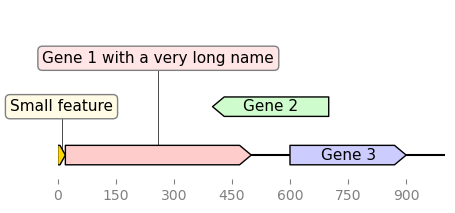

In [64]:
# !pip install dna_features_viewer
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord



features=[
    GraphicFeature(start=0, end=20, strand=+1, color="#ffd700",
                   label="Small feature"),
    GraphicFeature(start=20, end=500, strand=+1, color="#ffcccc",
                   label="Gene 1 with a very long name"),
    GraphicFeature(start=400, end=700, strand=-1, color="#cffccc",
                   label="Gene 2"),
    GraphicFeature(start=600, end=900, strand=+1, color="#ccccff",
                   label="Gene 3")
]
record = GraphicRecord(sequence_length=1000, features=features)
record.plot(figure_width=5)

(<Axes: >,
 ({GF(Small feature, 0-20 (1)): 0,
   GF(Gene 1 with a very long name, 20-500 (1)): 0,
   GF(Gene 2, 400-700 (-1)): 1.0,
   GF(Gene 3, 600-900 (1)): 0},
  {GF(Gene 1 with a very long name, 20-500 (1)): {'feature_y': -1.0596548213901706,
    'annotation_y': 0.45},
   GF(Gene 2, 400-700 (-1)): {'feature_y': -2.142427152334812,
    'annotation_y': 0.95},
   GF(Gene 3, 600-900 (1)): {'feature_y': -1.00314158748588,
    'annotation_y': 0.45},
   GF(Small feature, 0-20 (1)): {'feature_y': -0.0017809347217881966,
    'annotation_y': 0.7}}))

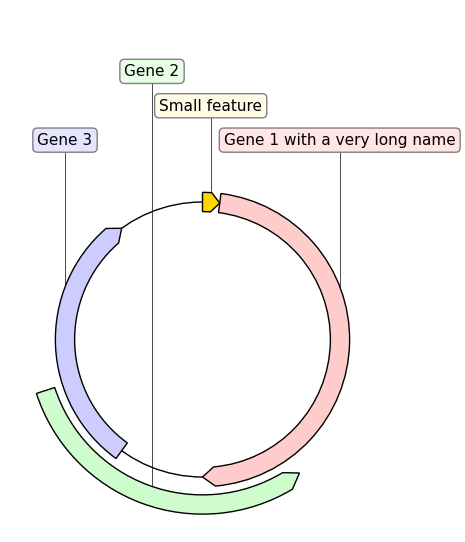

In [65]:
record = CircularGraphicRecord(sequence_length=1000, features=features)
record.plot(figure_width=5)

#### Creating a plot from GenBank file utilizing Biopython

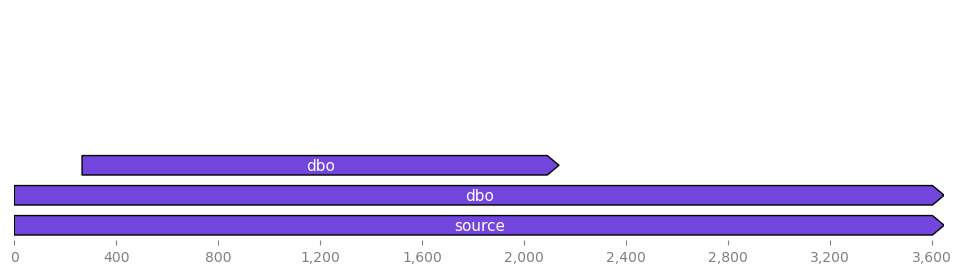

In [61]:
from dna_features_viewer import BiopythonTranslator
import matplotlib.pyplot as plt

genbank_file = "sequence.gb"

# Read the GenBank annotations and convert them to a graphic record
graphic_record = BiopythonTranslator().translate_record(genbank_file)

# Plot the annotated sequence
fig, ax = plt.subplots(figsize=(12, 3))
graphic_record.plot(ax=ax, strand_in_label_threshold=7)
plt.show()

In [68]:
len("""LPPQPSAAHQGRGGRSGLLPKGPAMLCRLCWLVSYSLAVLLLGCLLFLRKAAKPAGDPTAHQPFWAPPT
PRHSRCPPNHTVSSASLSLPSRHRLFLTYRHCRNFSILLEPSGCSKDTFLLLAIKSQPGHVERRAAIRST
WGRVGGWARGRQLKLVFLLGVAGSAPPAQLLAYESREFDDILQWDFTEDFFNLTLKELHLQRWVVAACPQ
AHFMLKGDDDVFVHVPNVLEFLDGWDPAQDLLVGDVIRQALPNRNTKVKYFIPPSMYRATHYPPYAGGGG
YVMSRATVRRLQAIMEDAELFPIDDVFVGMCLRRLGLSPMHHAGFKTFGIRRPLDPLDPCLYRGLLLVHR
LSPLEMWTMWALVTDEGLKCAAGPIPQR""")

382

**Exercise 1.** The restriction enzyme *DsaI* recognizes the sequences: CCGCGG, CCGTGG, CCACGG, CCATGG. Write a regular expression that checks whether a sequence contains its recognition site. The solution should not list all four full sequences explicitly. Compare your regex with cutting site returned by the `elucidate()` method (`Bio.Restriction` module).

**Exercise 2.** Write regular expressions that identify the following in the text below:
* all words beginning with m
* all words immediately followed by and, including and
* all 7-character words that do not begin with f
* all words of length at most 7 that end with ing

In [16]:
txt = """Would to heaven that the reader, emboldened and momentarily ferocious as he reads,
finds his wild and savage path through the desolate marshes of these dark and poisonous pages, 
without disorientation; for, unless he brings in his reading a rigorous logic and a tension of mind 
equal at least to his distrust, the mortal emanations of this book will soak his soul, as water sugar. 
It is not good for everybody to read the pages that follow; some alone will savor this bitter fruit without danger. 
Therefore, timid soul, before penetrating farther into such unexplored heaths, directs your heels back and not forward. 
Listen well to what I say to you: run your heels back and not forward, like the eyes of a son who, 
deviates respectfully from the august contemplation of the maternal side; 
or, rather, as an endless angle of chilly cranes of great meditation, which, during the winter, 
flies powerfully through the silence, with all sails stretched, towards a fixed point of the horizon, 
whence suddenly leaves a strange and strong wind, precursor of the storm. 
""".replace('\n', ' ')

**Exercise 3.** Find a plasmid (e.g. pUC19) sequence data in the Nucleotide database (https://www.ncbi.nlm.nih.gov/) and visualise it using `dna_features_viewer`.

**Exercise 4.** Using Biopython open the `data.fasta` file, read-in the sequence record data, write records with sequences longer than 380 to a new FASTA file. Calculate the isoelectric point for each of those.

**Exercise 5.** (optional task) Write a program that, for a given DNA sequence, finds all open reading frames (ORFs) and prints their translated amino acid sequences. An ORF (Open Reading Frame) is a sequence located between a START codon and a STOP codon. Use regular expressions. Assume the standard genetic code (e.g., from Exercise 3.1).

A complete solution should examine all 6 reading frames:

* three possible ribosome start offsets: [0:3], [1:4], [2:5]
* both DNA strands:
  - dna_seq (for RNA, replace T with U)
  - the reverse complement of dna_seq